In [ ]:
# Start venv
# python3 -m venv myenv
# source myenv/bin/activate


In [1]:
%pip install insightface opencv-python numpy onnxruntime
%pip install mtcnn
%pip install tensorflow
%pip install ultralytics --quiet

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [ ]:
import cv2
import numpy as np
import insightface
from insightface.app import FaceAnalysis
import matplotlib.pyplot as plt
import math
from ultralytics import YOLO  

# Load YOLO model (custom trained on faces or pretrained face model)
yolo_model = YOLO("/home/ayush/DSP_Project/best_yolo_model.pt")  # 🔁 Put your custom trained model here

# Initialize InsightFace
app = FaceAnalysis(name='buffalo_l', providers=['CPUExecutionProvider'])
app.prepare(ctx_id=0, det_size=(320, 320))

def extract_embedding(image_path, temp, printimage=False):
    img = cv2.imread(image_path)
    if img is None:
        print(f"❌ Error: Couldn't load '{image_path}'")
        return None

    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # YOLO inference
    results = yolo_model(img_rgb)
    detections = results[0].boxes
    print("RESULTS")
    print(results)
    
    if detections is None or len(detections) == 0:
        print(f"❌ No face detected in {image_path}")
        return None

    embeddings = []
    count = 0
    num_faces = len(detections)
    rows = min(5, num_faces)
    cols = math.ceil(num_faces / rows)

    if printimage:
        fig, ax = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
        ax = np.array(ax).reshape(rows, cols)

    for idx, box in enumerate(detections):
        x1, y1, x2, y2 = map(int, box.xyxy[0].cpu().numpy())
        x1, y1 = max(x1, 0), max(y1, 0)
        x2, y2 = min(x2, img.shape[1]), min(y2, img.shape[0])

        # Crop face
        face_crop = img[y1:y2, x1:x2]

        # Extract embedding using InsightFace
        detected_faces = app.get(face_crop)

        if len(detected_faces) > 0:
            embedding = detected_faces[0].normed_embedding
            embeddings.append(embedding)
            temp.append(face_crop)

            if printimage:
                row, col = divmod(idx, cols)
                ax[row, col].imshow(cv2.cvtColor(face_crop, cv2.COLOR_BGR2RGB))
                ax[row, col].set_title(f"Face {idx + 1}")
                ax[row, col].axis("off")

    return embeddings


Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/1k3d68.onnx landmark_3d_68 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/2d106det.onnx landmark_2d_106 ['None', 3, 192, 192] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/det_10g.onnx detection [1, 3, '?', '?'] 127.5 128.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/genderage.onnx genderage ['None', 3, 96, 96] 0.0 1.0
Applied providers: ['CPUExecutionProvider'], with options: {'CPUExecutionProvider': {}}
find model: /home/ayush/.insightface/models/buffalo_l/w600k_r50.onnx recognition ['None', 3, 112, 112] 127.5 127.5
set det

In [4]:
import os
import pickle
import numpy as np

REFERENCE_PATH = "/home/ayush/DSP_Project/faces"

def create_composite_embeddings():
    reference_embeddings = {}

    for person in os.listdir(REFERENCE_PATH):
        person_path = os.path.join(REFERENCE_PATH, person)
        if not os.path.isdir(person_path):
            continue
        
        embeddings = []
        for img_file in os.listdir(person_path):
            image_path = os.path.join(person_path, img_file)
            temp2 = []
            embedding = extract_embedding(image_path, temp2)

            if embedding is not None:
                embedding = np.array(embedding).squeeze()  # Ensures correct shape
                embeddings.append(embedding)

        if embeddings:
            try:
                composite_embedding = np.mean(np.vstack(embeddings), axis=0)
                reference_embeddings[person] = composite_embedding
                print(f"✅ Composite embedding generated for {person}")
            except ValueError as e:
                print(f"❌ Error merging embeddings for {person}: {e}")

    # Save embeddings to file
    with open("reference_embeddings.pkl", "wb") as f:
        pickle.dump(reference_embeddings, f)

    print("✅ All reference embeddings saved successfully.")

In [26]:
create_composite_embeddings()


0: 384x640 1 face, 831.3ms
Speed: 3.9ms preprocess, 831.3ms inference, 1.7ms postprocess per image at shape (1, 3, 384, 640)

0: 640x288 1 face, 528.9ms
Speed: 44.7ms preprocess, 528.9ms inference, 0.6ms postprocess per image at shape (1, 3, 640, 288)

0: 640x384 1 face, 633.6ms
Speed: 43.8ms preprocess, 633.6ms inference, 3.1ms postprocess per image at shape (1, 3, 640, 384)

0: 640x384 1 face, 667.4ms
Speed: 44.1ms preprocess, 667.4ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 384)

0: 288x640 1 face, 588.2ms
Speed: 44.0ms preprocess, 588.2ms inference, 0.6ms postprocess per image at shape (1, 3, 288, 640)

0: 288x640 1 face, 474.5ms
Speed: 41.7ms preprocess, 474.5ms inference, 0.7ms postprocess per image at shape (1, 3, 288, 640)

0: 640x384 1 face, 571.0ms
Speed: 42.9ms preprocess, 571.0ms inference, 0.7ms postprocess per image at shape (1, 3, 640, 384)
✅ Composite embedding generated for Rachit

0: 640x288 1 face, 492.4ms
Speed: 48.7ms preprocess, 492.4ms inferen

In [28]:
import pickle
import numpy as np

# Load reference embeddings
with open("reference_embeddings.pkl", "rb") as f:
    reference_embeddings = pickle.load(f)

# Convert reference embeddings (M×512) to a NumPy array of shape (M, 512)
persons = list(reference_embeddings.keys())  # List of person names
ref_matrix = np.array([reference_embeddings[person] for person in persons])  # Shape: (M, 512)

# Function to identify persons based on current embeddings
def identify_person(group_embeddings, threshold=0.5):
    group_embeddings = np.array(group_embeddings)  # Shape: (N, 512)

    # Invert current embeddings (N×512 → 512×N)
    group_matrix = group_embeddings.T  # Shape: (512, N)

    # Compute similarity using matrix multiplication (M×512) · (512×N) = (M×N)
    similarity_matrix = np.dot(ref_matrix, group_matrix)  # Shape: (M, N)

    # Normalize similarity scores (optional)
    similarity_matrix = (similarity_matrix - similarity_matrix.min()) / (similarity_matrix.max() - similarity_matrix.min())

    match_results = []

    # Iterate through each row (M) — checking reference persons
    for i, similarities in enumerate(similarity_matrix):
        best_idx = np.argmax(similarities)  # Index of max similarity
        best_score = similarities[best_idx]  # Max similarity score

        if best_score > threshold:  # Check threshold
            match_results.append((persons[i], best_idx, best_score))

    return match_results




0: 480x640 38 faces, 831.2ms
Speed: 18.9ms preprocess, 831.2ms inference, 1.8ms postprocess per image at shape (1, 3, 480, 640)


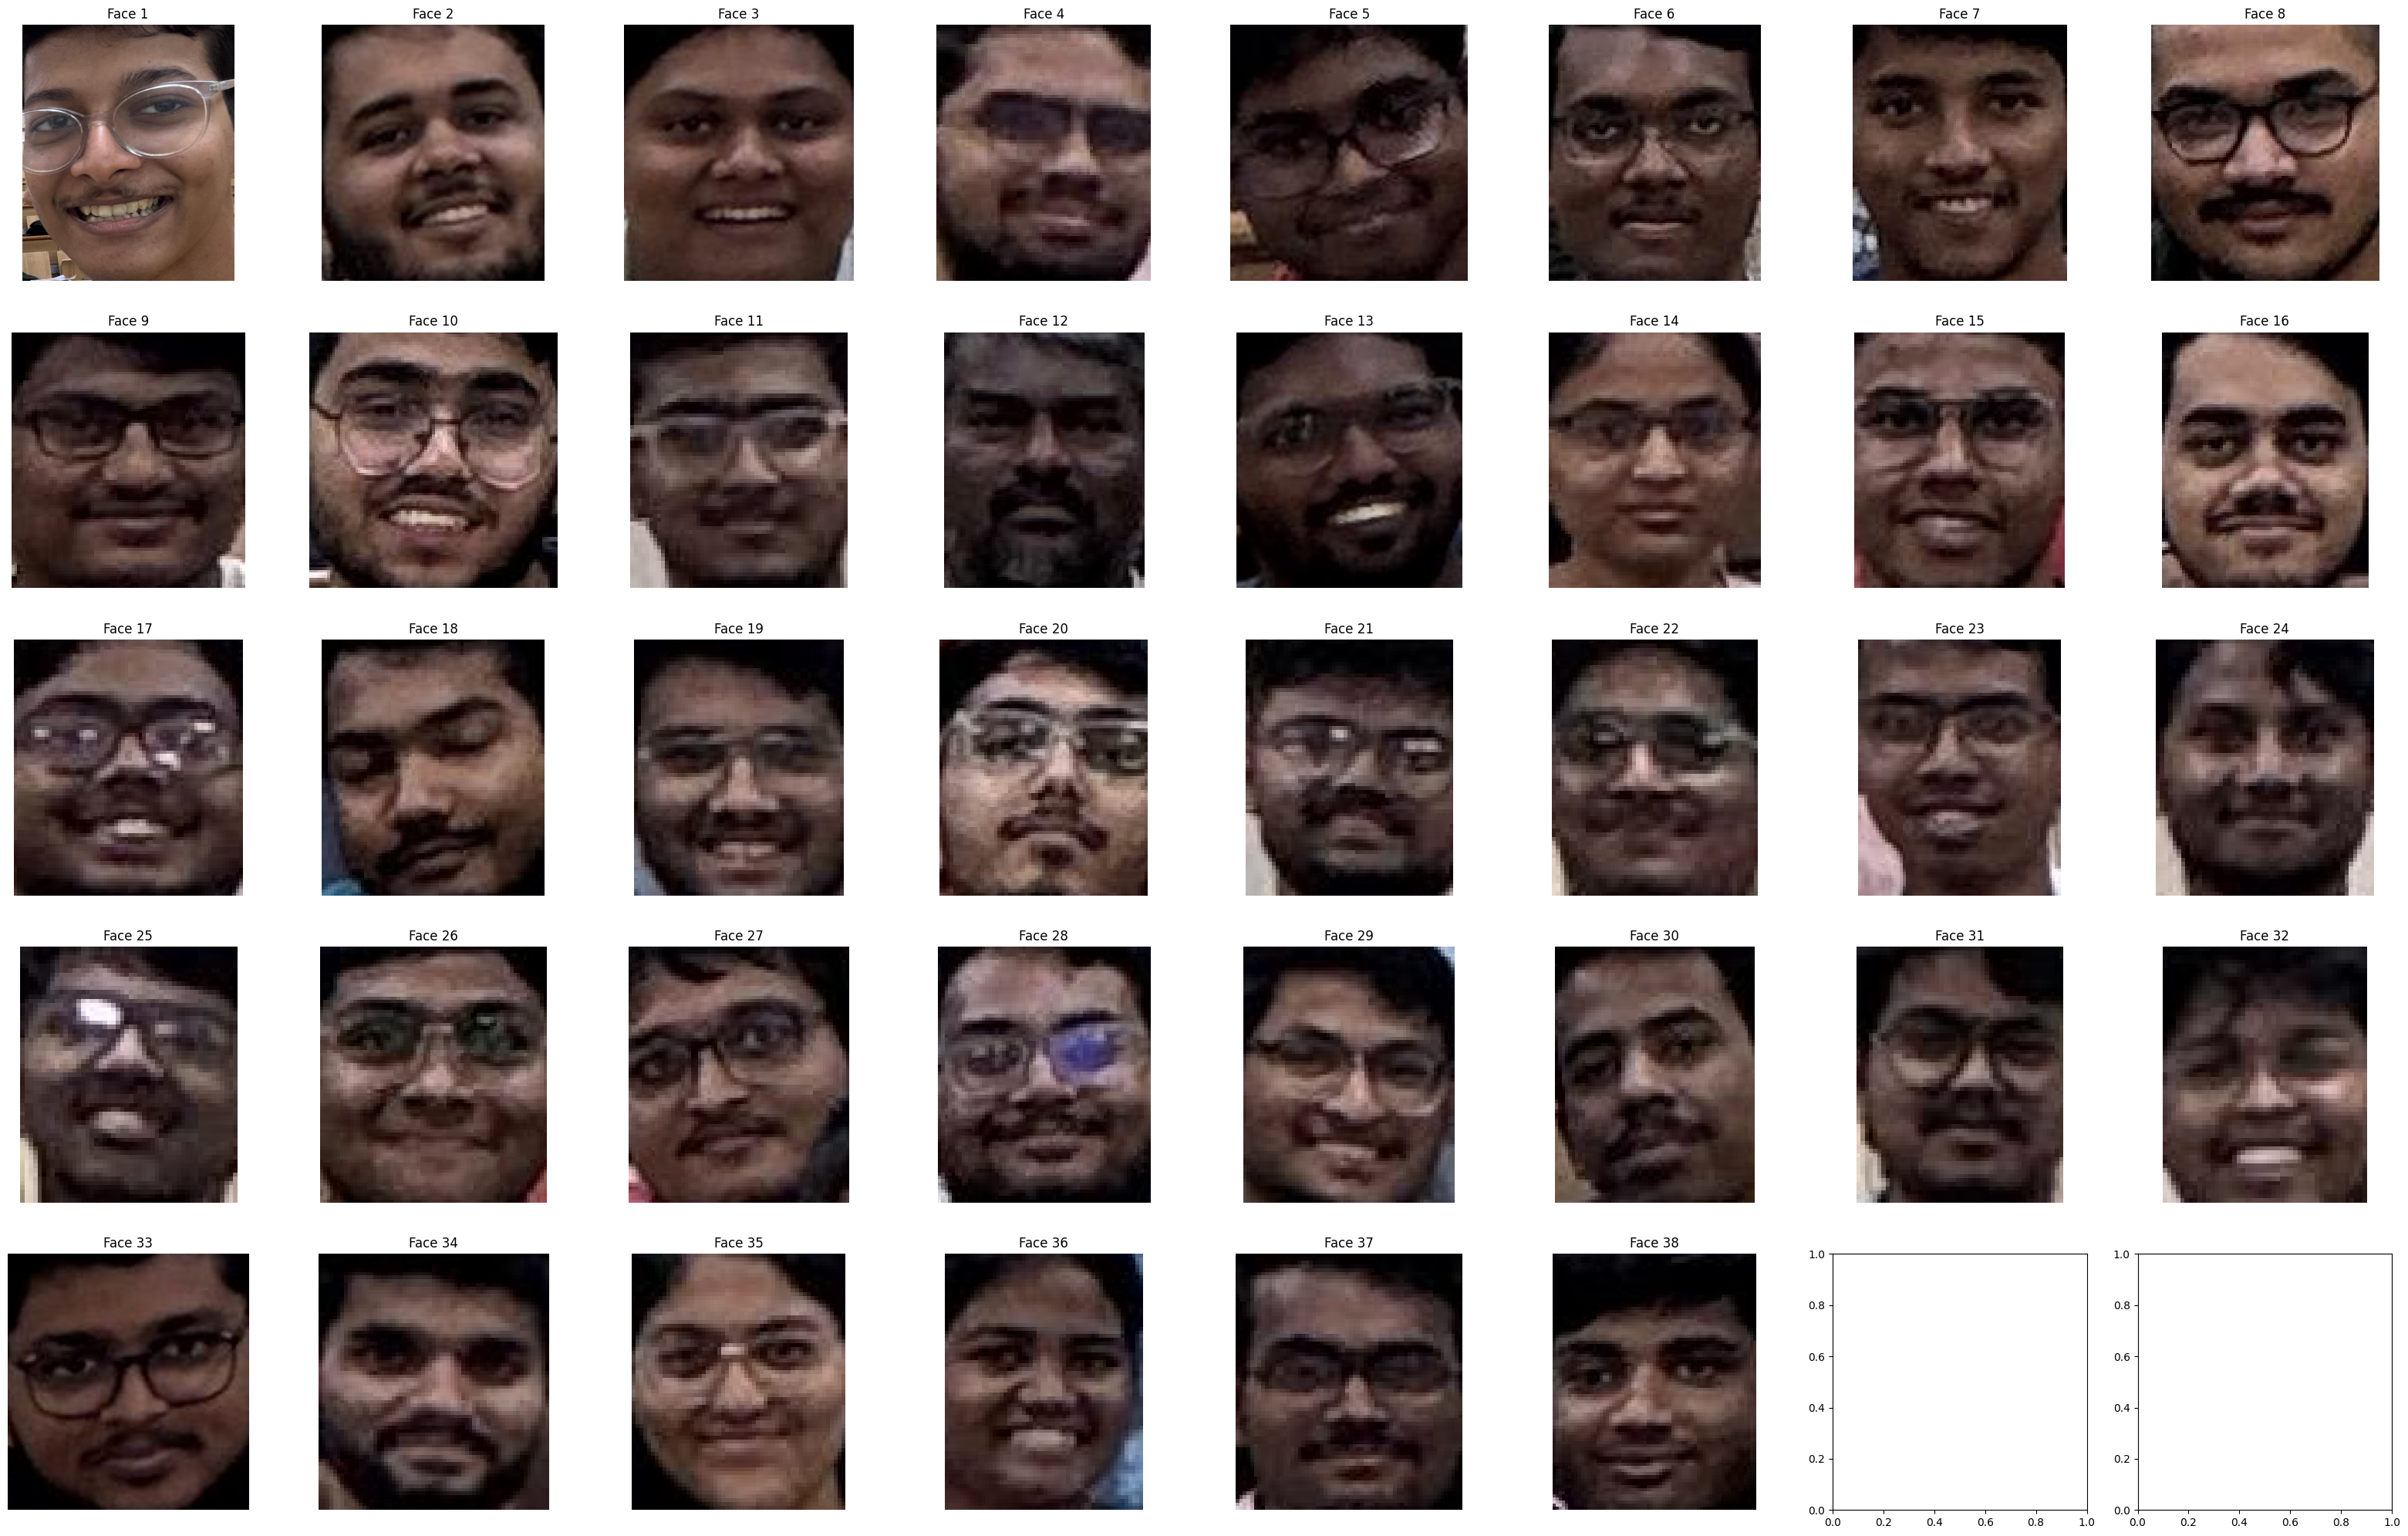

In [29]:
temp2=[]
embedding_vectors2 = extract_embedding("/home/ayush/DSP_Project/test_images/5all.jpg",temp2,True)

In [22]:
print(len(embedding_vectors2))


38


In [30]:
matches = identify_person(embedding_vectors2, 0.65)

# Sort matches by confidence score in descending order
matches.sort(key=lambda x: x[2], reverse=True)

# Print results
for idx, person, score in matches:
    print(f"Face {idx} matches {person} with confidence {score:.2f}")

Face Rohan Rudra matches 6 with confidence 1.00
Face Sreekar matches 5 with confidence 0.94
Face Ayush Gupta matches 7 with confidence 0.91
Face Aditya Abhilash matches 22 with confidence 0.85
Face Rachit matches 0 with confidence 0.76
